# Milestone 2

Nama: Syauqiya Hasna

Batch: FTDS-044-HCK

# 1. Perkenalan 

proyek ini dibuat dalam rangka membuat milestone 2. dataset student ini digunakan untuk melihat status akademik student berdasarkan informasi yang tersedia pada dataset. target yang terdiri dari 3 kelas yaitu dropout, enrolled dan  graduate 

disini dataset yang digunakan berasal dari url berikut

url: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success  

tujuan dari proyek ini adalah 
- melihat gambaran data dan pola di bagian EDA
- menyiapkan data supaya bisa digunakan untuk proses modeling
- membandingkan klasifikasi model menggunakan cross validation
- menyimpan model untuk digunakan pada file `P1M2_Syauqiya_Hasna.ipynb`



# 2. import libraries

In [374]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pickle



# 3. Data Loading

ini dilanjut dengan baca dataset, tapi ini memisahkannya dengan ; karena pada dataset yang tersimpan pada data.csv seperti itu


In [375]:
df = pd.read_csv('data.csv', sep=';')

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666.666.666.666.600,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.4,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.0,0,13.9,-0.3,0.79,Graduate


In [376]:
df.shape

(4424, 37)

In [377]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

dilanjutkan dengan merapihkan nama pada kolom, disini terdapat typo nacionality dan diubah menjadi nationality, dan juga ada beberapa kesalahan dalam penulisan dengan underscore jadi underscore di akhir dan di depan sebelum judul kolum agar lebih rapih.

In [378]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace("'", "", regex=False)
df.columns = df.columns.str.replace(r'[^a-z0-9]+', '_', regex=True)
df.columns = df.columns.str.strip('_')
df = df.rename(columns={'nacionality': 'nationality'})

df.columns

Index(['marital_status', 'application_mode', 'application_order', 'course',
       'daytime_evening_attendance', 'previous_qualification',
       'previous_qualification_grade', 'nationality', 'mothers_qualification',
       'fathers_qualification', 'mothers_occupation', 'fathers_occupation',
       'admission_grade', 'displaced', 'educational_special_needs', 'debtor',
       'tuition_fees_up_to_date', 'gender', 'scholarship_holder',
       'age_at_enrollment', 'international',
       'curricular_units_1st_sem_credited',
       'curricular_units_1st_sem_enrolled',
       'curricular_units_1st_sem_evaluations',
       'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade',
       'curricular_units_1st_sem_without_evaluations',
       'curricular_units_2nd_sem_credited',
       'curricular_units_2nd_sem_enrolled',
       'curricular_units_2nd_sem_evaluations',
       'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade',
       'curricular_units_2nd_sem_wit

In [379]:
df.head()

,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nationality,mothers_qualification,fathers_qualification,...,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666.666.666.666.600,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.4,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.0,0,13.9,-0.3,0.79,Graduate


In [380]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   marital_status                                4424 non-null   int64  
 1   application_mode                              4424 non-null   int64  
 2   application_order                             4424 non-null   int64  
 3   course                                        4424 non-null   int64  
 4   daytime_evening_attendance                    4424 non-null   int64  
 5   previous_qualification                        4424 non-null   int64  
 6   previous_qualification_grade                  4424 non-null   float64
 7   nationality                                   4424 non-null   int64  
 8   mothers_qualification                         4424 non-null   int64  
 9   fathers_qualification                         4424 non-null   i

berdasarkan `df.info` disini sebagian besar kolom sudah berbentuk numeric, tetapi pada kolom `curricular_units_1st_sem_grade` dan `curricular_units_2nd_sem_grade` masih terbaca sebagai `object`

2 kolom tersebut formatnya perlu diperbaiki menjadi numeric sebelum masuk EDA dan modeling, karena apabila tidak diubah dan tetap menjadi `object` kolom tersebut bisa terlihat sebagai kategorikal

In [381]:
df.isnull().sum()

marital_status                                  0
application_mode                                0
application_order                               0
course                                          0
daytime_evening_attendance                      0
previous_qualification                          0
previous_qualification_grade                    0
nationality                                     0
mothers_qualification                           0
fathers_qualification                           0
mothers_occupation                              0
fathers_occupation                              0
admission_grade                                 0
displaced                                       0
educational_special_needs                       0
debtor                                          0
tuition_fees_up_to_date                         0
gender                                          0
scholarship_holder                              0
age_at_enrollment                               0


disini tidak adanya missing value pada dataset

In [382]:
df.duplicated().sum()

0

disini juga tidak adanya data duplicate, jadi tidak perlu melakukan drop duplicate

In [383]:
df['target'].value_counts()

target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

jumlah pada target belum seimbang, bagian graduate paling banyak dengan 2.209 student, lalu dropout 1.421 student, dan enrolled 794 student

artinya model nantinya akan lebih sering melihat data graduate dibanding enrolled. karena itu, pada train-test split digunakan stratify supaya proporsi ketiga kelas tetap terjaga, dan pada evaluasi model digunakan F1_weighted selain accuracy

In [384]:
def fix_grade(value):
    value = str(value)

    if value.count('.') > 1:
        first_dot = value.find('.')
        value = value[:first_dot + 1] + value[first_dot + 1:].replace('.', '')

    return pd.to_numeric(value, errors='coerce')


df['curricular_units_1st_sem_grade'] = (df['curricular_units_1st_sem_grade'].apply(fix_grade))
df['curricular_units_2nd_sem_grade'] = (df['curricular_units_2nd_sem_grade'].apply(fix_grade))

disini format grade dibenerin dulu karena sebelumnya ada nilai yang punya lebih dari satu tanda titik sehingga terbaca sebagai text. setelah dibersihkan, kedua kolom grade diubah menjadi numeric

# 4. EDA

### Distribusi Status Akademik

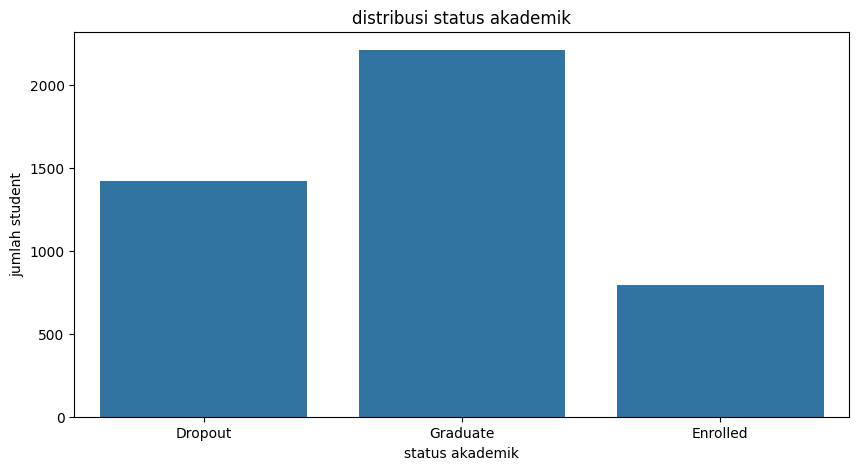

In [385]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='target')

plt.title('distribusi status akademik')
plt.xlabel('status akademik')
plt.ylabel('jumlah student')

plt.show()

status graduate punya jumlah paling banyak, sedangkan enrolled paling sedikit. perbedaannya cukup jelas, jadi dari awal sudah kelihatan kalau target mengalami ketidakseimbangan

### Distribusi Umur Saat Mendaftar

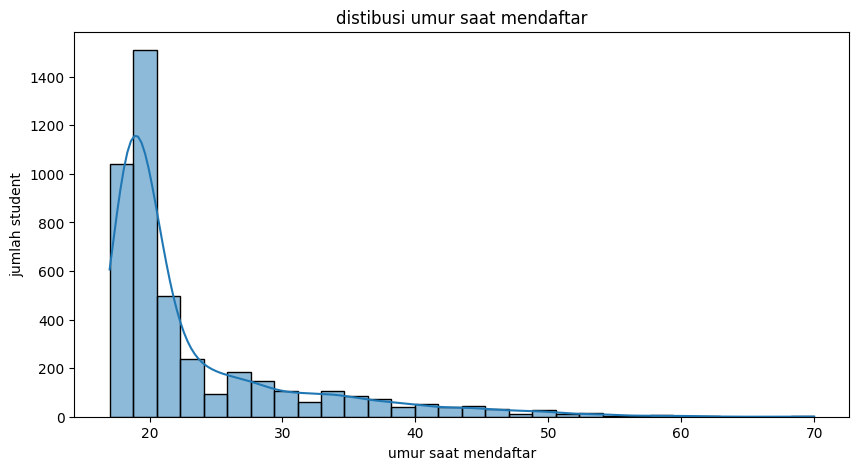

In [386]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age_at_enrollment', bins=30, kde=True)

plt.title('distibusi umur saat mendaftar')
plt.xlabel('umur saat mendaftar')
plt.ylabel('jumlah student')

plt.show()

sebagian besar student mendaftar pada umur sekitar 18 sampai awal 20-an. distribusinya condong ke kanan karena masih ada student yang mendaftar di umur yang lebih tua, tapi jumlahnya semakin sedikit. jadi mayoritas data memang berasal dari student usia kuliah pada umumnya, tetapi tetap ada variasi usia yang cukup lebar

### Status Akademik Berdasarkan Pembayaran Tuition Fee

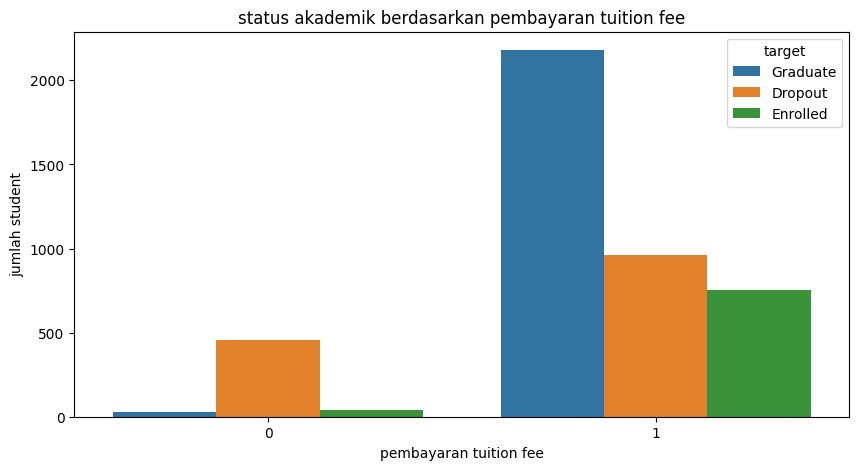

In [387]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='tuition_fees_up_to_date',
    hue='target'
)

plt.title('status akademik berdasarkan pembayaran tuition fee')
plt.xlabel('pembayaran tuition fee')
plt.ylabel('jumlah student')

plt.show()

student dengan tuition fee yang "up to date" lebih banyak berada pada status graduate. sebaliknya, pada student yang pembayarannya tidak "up to date", jumlah dropout terlihat lebih dominan. dari grafik ini kelihatan kalau kondisi pembayaran punya hubungan dengan status akademik

### Status Akademik Berdasarkan Status Debtor

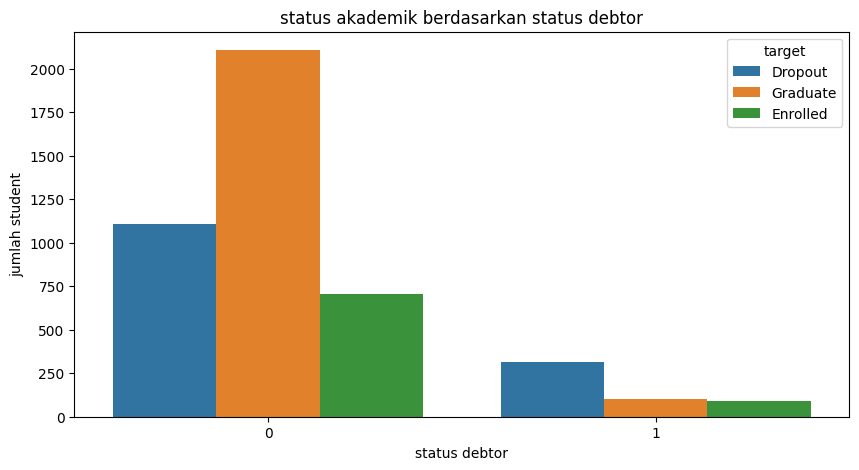

In [388]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='debtor',
    hue='target'
)

plt.title('status akademik berdasarkan status debtor')
plt.xlabel('status debtor')
plt.ylabel('jumlah student')

plt.show()

pada student yang bukan "debtor, status Graduate paling dominan. sedangkan pada student yang punya status "debtor", jumlah Dropout terlihat lebih banyak. polanya searah dengan hasil tuition fee sebelumnya, yaitu kondisi finansial kelihatan cukup berkaitan dengan keberlanjutan studi. Feature debtor dan tuition_fees_up_to_date jadi cukup menarik untuk dipertahankan dalam modeling

### Status Akademik Berdasarkan Penerima Beasiswa

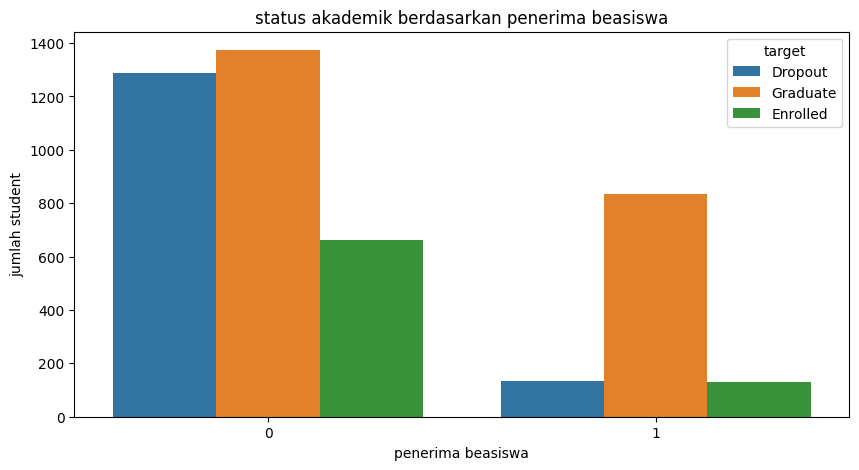

In [389]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='scholarship_holder',
    hue='target'
)

plt.title('status akademik berdasarkan penerima beasiswa')
plt.xlabel('penerima beasiswa')
plt.ylabel('jumlah student')

plt.show()

student penerima beasiswa lebih banyak berada pada kelas graduate, sementara jumlah dropout-nya lebih sedikit. Pada student yang tidak menerima beasiswa, jumlah dropout terlihat lebih besar. hasil ini nunjukin kalau status beasiswa juga punya pola yang berbeda antar kelas target. walaupun begitu, beasiswa bukan satu-satunya faktor karena status akademik student tetap dipengaruhi oleh banyak feature lain

### Nilai Semester Pertama Berdasarkan Status Akademik

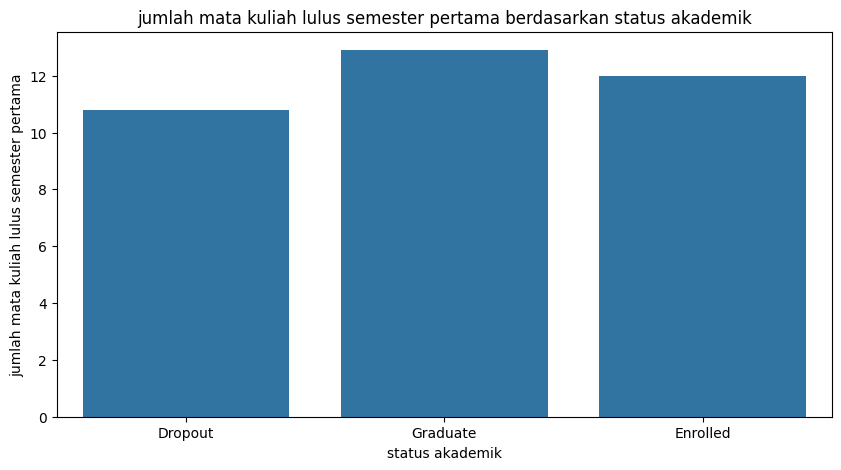

In [390]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x='target',
    y='curricular_units_1st_sem_grade',
    estimator='median',
    errorbar=None
)

plt.title('jumlah mata kuliah lulus semester pertama berdasarkan status akademik')
plt.xlabel('status akademik')
plt.ylabel('jumlah mata kuliah lulus semester pertama')

plt.show()

student dengan status graduate punya median nilai semester pertama yang lebih tinggi dibandingkan dropout dan Enrolled. sementara itu, kelompok dropout punya nilai yang lebih rendah. jadi performa akademik sejak semester pertama sudah kelihatan cukup membedakan ketiga status. ini juga masuk akal untuk dicek lebih lanjut pada feature importance karena nilai dan jumlah mata kuliah yang lulus muncul langsung selama proses studi

### Hubungan Nilai dan Mata Kuliah Lulus Semester Pertama

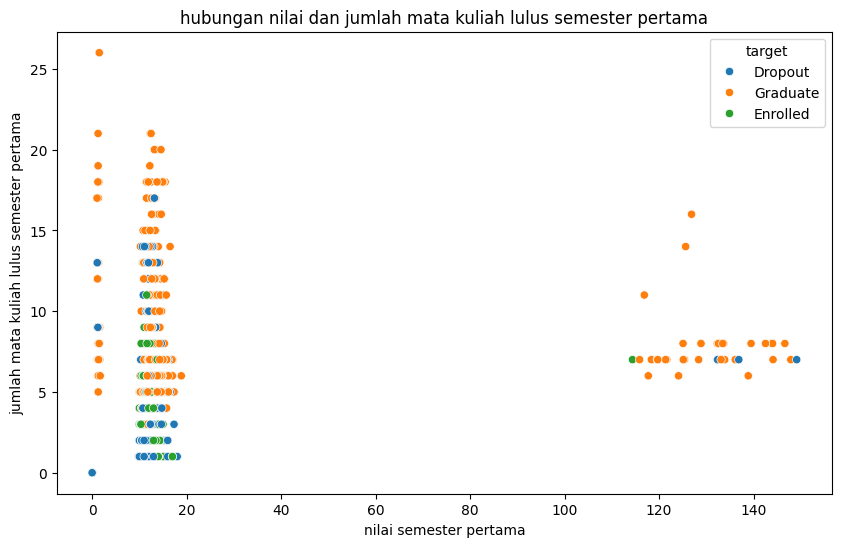

In [391]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='curricular_units_1st_sem_grade',
    y='curricular_units_1st_sem_approved',
    hue='target',
)

plt.title('hubungan nilai dan jumlah mata kuliah lulus semester pertama')
plt.xlabel('nilai semester pertama')
plt.ylabel('jumlah mata kuliah lulus semester pertama')

plt.show()

secara umum, student dengan nilai semester pertama yang lebih baik juga cenderung punya lebih banyak mata kuliah yang lulus. titik Graduate lebih banyak muncul pada area nilai dan jumlah mata kuliah lulus yang lebih tinggi, sedangkan dropout lebih banyak muncul pada area yang lebih rendah. masih ada beberapa nilai yang terlihat jauh dari mayoritas data. Karena itu, pengecekan format data dan outlier tetap dilakukan sebelum modeling supaya nilai yang tidak wajar tidak langsung dianggap normal

# 5. Feature Engineering

In [392]:
X = df.drop(columns='target')
y = df['target']

In [393]:
# ini buat ngebagi dataset menjadi train-set dan test-set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

# nampilin train dan test set x dan y
print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

X_train shape: (3539, 36)
X_test shape : (885, 36)
y_train shape: (3539,)
y_test shape : (885,)


data dibagi menjadi 80% train dan 20% test. hasilnya ada 3.539 data untuk train dan 885 data untuk test. disini stratify dipakai supaya perbandingan dropout, enrolled dan graduate pada train dan test tetap mengikuti data awal karena targetnya belum seimbang

In [394]:
# misahin kolom kategorikal
categorical_features = [
    'marital_status',
    'application_mode',
    'course',
    'daytime_evening_attendance',
    'previous_qualification',
    'nationality',
    'mothers_qualification',
    'fathers_qualification',
    'mothers_occupation',
    'fathers_occupation',
    'displaced',
    'educational_special_needs',
    'debtor',
    'tuition_fees_up_to_date',
    'gender',
    'scholarship_holder',
    'international'
]

In [395]:
# misahin kolom numerikal
numerical_features = [
    'application_order',
    'previous_qualification_grade',
    'admission_grade',
    'age_at_enrollment',
    'curricular_units_1st_sem_credited',
    'curricular_units_1st_sem_enrolled',
    'curricular_units_1st_sem_evaluations',
    'curricular_units_1st_sem_approved',
    'curricular_units_1st_sem_grade',
    'curricular_units_1st_sem_without_evaluations',
    'curricular_units_2nd_sem_credited',
    'curricular_units_2nd_sem_enrolled',
    'curricular_units_2nd_sem_evaluations',
    'curricular_units_2nd_sem_approved',
    'curricular_units_2nd_sem_grade',
    'curricular_units_2nd_sem_without_evaluations',
    'unemployment_rate',
    'inflation_rate',
    'gdp'
]

In [396]:
for cat in categorical_features:
    count = X_train[cat].nunique()
    print(f"{cat}: {count}")


marital_status: 6
application_mode: 17
course: 17
daytime_evening_attendance: 2
previous_qualification: 17
nationality: 20
mothers_qualification: 28
fathers_qualification: 32
mothers_occupation: 31
fathers_occupation: 42
displaced: 2
educational_special_needs: 2
debtor: 2
tuition_fees_up_to_date: 2
gender: 2
scholarship_holder: 2
international: 2


beberapa feature kategorikal punya jumlah kategori yang cukup banyak, contohnya "fathers_occupation" ada 42 kategori, "mothers_occupation" ada 31 kategori dan "fathers_qualification" ada 32 kategori. jadi nanti setelah dilakukan one hot encoding jumlah kolom bisa bertambah karena setiap kategori akan dipisah menjadi kolom baru

In [397]:
num_train = X_train._get_numeric_data()
for k, v in num_train.items():
  q1 = v.quantile(0.25)
  q3 = v.quantile(0.75)
  iqr = q3 - q1
  v_col = v[(v <= q1 - 1.5 * iqr) | (v >= q3 + 1.5 * iqr)]
  perc = len(v_col)* 100.0 / len(num_train)
  print(f"{k}: {perc}")

marital_status: 100.0
application_mode: 0.0
application_order: 12.291607798813224
course: 9.946312517660356
daytime_evening_attendance: 100.0
previous_qualification: 100.0
previous_qualification_grade: 4.068946029951964
nationality: 100.0
mothers_qualification: 0.0
fathers_qualification: 0.0
mothers_occupation: 3.84289347273241
fathers_occupation: 3.9276631816897427
admission_grade: 2.062729584628426
displaced: 0.0
educational_special_needs: 100.0
debtor: 100.0
tuition_fees_up_to_date: 100.0
gender: 0.0
scholarship_holder: 100.0
age_at_enrollment: 11.104831873410568
international: 100.0
curricular_units_1st_sem_credited: 100.0
curricular_units_1st_sem_enrolled: 11.04831873410568
curricular_units_1st_sem_evaluations: 12.687199773947443
curricular_units_1st_sem_approved: 4.266742017519073
curricular_units_1st_sem_grade: 19.553546199491382
curricular_units_1st_sem_without_evaluations: 100.0
curricular_units_2nd_sem_credited: 100.0
curricular_units_2nd_sem_enrolled: 9.578977112178581
curri

hasil pengecekan outlier disini masih ikut membaca beberapa kolom kategorikal yang bentuknya angka. jadi nilai 100% pada beberapa feature kategorikal tidak dianggap sebagai outlier numerikal. untuk feature numerikal, outlier cukup banyak terlihat pada "curricular_units_2nd_sem_grade", "curricular_units_1st_sem_grade" dan beberapa feature jumlah mata kuliah. outliernya tidak langsung dibuang karena masih bisa jadi kondisi student yang memang ada pada data

In [398]:
X_train.isnull().sum()

marital_status                                  0
application_mode                                0
application_order                               0
course                                          0
daytime_evening_attendance                      0
previous_qualification                          0
previous_qualification_grade                    0
nationality                                     0
mothers_qualification                           0
fathers_qualification                           0
mothers_occupation                              0
fathers_occupation                              0
admission_grade                                 0
displaced                                       0
educational_special_needs                       0
debtor                                          0
tuition_fees_up_to_date                         0
gender                                          0
scholarship_holder                              0
age_at_enrollment                               0


setelah data dibagi menjadi train dan test, pada X_train juga tetap tidak ada missing value. jadi tidak ada data yang perlu dihapus atau diisi khusus karena missing value pada bagian ini

In [399]:
label = LabelEncoder()
y_train = label.fit_transform(y_train)
y_test = label.transform(y_test)

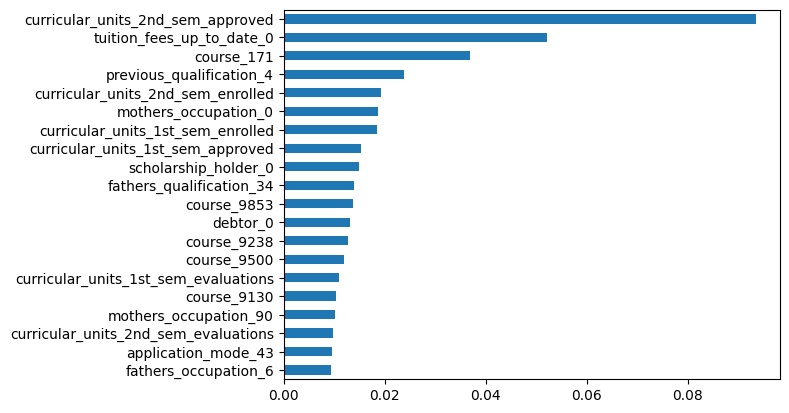

In [400]:
model = XGBClassifier()
X_train_ohe = pd.get_dummies(X_train, columns=categorical_features, dtype=int)
y_train_ohe = y_train.copy()

model.fit(X_train_ohe, y_train_ohe)

feat_importances = pd.Series(model.feature_importances_, index=X_train_ohe.columns)
feat_importances.nlargest(20).plot(kind='barh').invert_yaxis()

berdasarkan feature importance, "curricular_units_2nd_sem_approved" jadi feature yang paling menonjol, lalu diikuti "tuition_fees_up_to_date". beberapa feature seperti course, previous qualification dan jumlah mata kuliah yang diambil juga muncul pada urutan atas. hasil ini masih berupa feature importance dari xgboost sebelum modeling utama, jadi dipakai untuk melihat gambaran feature mana yang cukup berpengaruh terhadap target

In [401]:
X_train.drop(['Unnamed: 0','id'], axis=1, inplace=True, errors='ignore')

In [402]:
X_test.drop(['Unnamed: 0','id'], axis=1, inplace=True, errors='ignore')

In [403]:
X_train.columns, X_test.columns

(Index(['marital_status', 'application_mode', 'application_order', 'course',
        'daytime_evening_attendance', 'previous_qualification',
        'previous_qualification_grade', 'nationality', 'mothers_qualification',
        'fathers_qualification', 'mothers_occupation', 'fathers_occupation',
        'admission_grade', 'displaced', 'educational_special_needs', 'debtor',
        'tuition_fees_up_to_date', 'gender', 'scholarship_holder',
        'age_at_enrollment', 'international',
        'curricular_units_1st_sem_credited',
        'curricular_units_1st_sem_enrolled',
        'curricular_units_1st_sem_evaluations',
        'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade',
        'curricular_units_1st_sem_without_evaluations',
        'curricular_units_2nd_sem_credited',
        'curricular_units_2nd_sem_enrolled',
        'curricular_units_2nd_sem_evaluations',
        'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade',
        'curricular_

disini kolom "id" dan "unnamed: 0" dipastikan tidak ikut digunakan pada train dan test karena kolom tersebut hanya menjadi penanda data dan tidak menjelaskan kondisi akademik student. setelah itu kolom pada train dan test tetap sama sehingga bisa dilanjut ke preprocessing

In [404]:
encoded_column = categorical_features

In [405]:
preprocessing = ColumnTransformer([
    ('numerical', Pipeline([
        ('imputer', SimpleImputer()),
        ('scaler', MinMaxScaler())
    ]), numerical_features),

    ('categorical_nominal', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), encoded_column)
])

untuk feature numerikal digunakan "MinMaxScaler", sedangkan feature kategorikal diubah menggunakan "OneHotEncoder". preprocessing ini dimasukkan ke dalam pipeline supaya proses yang sama bisa langsung diterapkan saat training maupun saat model menerima data baru

# 6. Model Definition

In [406]:
# pipeline logistic regression
pipe_logreg = Pipeline([
    ('transformer', preprocessing),
    ('classifier', LogisticRegression(max_iter=1000))
])

# pipeline knn
pipe_knn = Pipeline([
    ('transformer', preprocessing),
    ('classifier', KNeighborsClassifier(n_neighbors=3))
])

# pipeline svm
pipe_svm = Pipeline([
    ('transformer', preprocessing),
    ('classifier', SVC(kernel='linear'))
])

# pipeline Decision Tree
pipe_dt = Pipeline([
    ('transformer', preprocessing),
    ('classifier', DecisionTreeClassifier())
])

# pipeline Random Forest
pipe_rf = Pipeline([
    ('transformer', preprocessing),
    ('classifier', RandomForestClassifier())
])

# pipeline XGBoost
pipe_xgb = Pipeline([
    ('transformer', preprocessing),
    ('classifier', XGBClassifier())
])

# 7. Model Training

In [407]:
pipe_logreg.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['application_order',
                                                   'previous_qualification_grade',
                                                   'admission_grade',
                                                   'age_at_enrollment',
                                                   'curricular_units_1st_sem_credited',
                                                   'curricular_units_1st_sem_enrolled',
                                                   'curricular_units_1st_sem_evaluations',
                                                   '...
                                                   'application_mode', 'course',
                                                   'daytime_evening_attendance',
                                                   'previous_qualification',
                                                   'nationality',
                                                   'mothers_qualification',
                                                   'fathers_qualification',
                                                   'mothers_occupation',
                                                   'fathers_occupation',
                                                   'displaced',
                                                   'educational_special_needs',
                                                   'debtor',
                                                   'tuition_fees_up_to_date',
                                                   'gender',
                                                   'scholarship_holder',
                                                   'international'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [408]:
pipe_knn.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['application_order',
                                                   'previous_qualification_grade',
                                                   'admission_grade',
                                                   'age_at_enrollment',
                                                   'curricular_units_1st_sem_credited',
                                                   'curricular_units_1st_sem_enrolled',
                                                   'curricular_units_1st_sem_evaluations',
                                                   '...
                                                   'application_mode', 'course',
                                                   'daytime_evening_attendance',
                                                   'previous_qualification',
                                                   'nationality',
                                                   'mothers_qualification',
                                                   'fathers_qualification',
                                                   'mothers_occupation',
                                                   'fathers_occupation',
                                                   'displaced',
                                                   'educational_special_needs',
                                                   'debtor',
                                                   'tuition_fees_up_to_date',
                                                   'gender',
                                                   'scholarship_holder',
                                                   'international'])])),
                ('classifier', KNeighborsClassifier(n_neighbors=3))])

In [409]:
pipe_svm.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['application_order',
                                                   'previous_qualification_grade',
                                                   'admission_grade',
                                                   'age_at_enrollment',
                                                   'curricular_units_1st_sem_credited',
                                                   'curricular_units_1st_sem_enrolled',
                                                   'curricular_units_1st_sem_evaluations',
                                                   '...
                                                  ['marital_status',
                                                   'application_mode', 'course',
                                                   'daytime_evening_attendance',
                                                   'previous_qualification',
                                                   'nationality',
                                                   'mothers_qualification',
                                                   'fathers_qualification',
                                                   'mothers_occupation',
                                                   'fathers_occupation',
                                                   'displaced',
                                                   'educational_special_needs',
                                                   'debtor',
                                                   'tuition_fees_up_to_date',
                                                   'gender',
                                                   'scholarship_holder',
                                                   'international'])])),
                ('classifier', SVC(kernel='linear'))])

In [410]:
pipe_dt.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['application_order',
                                                   'previous_qualification_grade',
                                                   'admission_grade',
                                                   'age_at_enrollment',
                                                   'curricular_units_1st_sem_credited',
                                                   'curricular_units_1st_sem_enrolled',
                                                   'curricular_units_1st_sem_evaluations',
                                                   '...
                                                   'application_mode', 'course',
                                                   'daytime_evening_attendance',
                                                   'previous_qualification',
                                                   'nationality',
                                                   'mothers_qualification',
                                                   'fathers_qualification',
                                                   'mothers_occupation',
                                                   'fathers_occupation',
                                                   'displaced',
                                                   'educational_special_needs',
                                                   'debtor',
                                                   'tuition_fees_up_to_date',
                                                   'gender',
                                                   'scholarship_holder',
                                                   'international'])])),
                ('classifier', DecisionTreeClassifier())])

In [411]:
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['application_order',
                                                   'previous_qualification_grade',
                                                   'admission_grade',
                                                   'age_at_enrollment',
                                                   'curricular_units_1st_sem_credited',
                                                   'curricular_units_1st_sem_enrolled',
                                                   'curricular_units_1st_sem_evaluations',
                                                   '...
                                                   'application_mode', 'course',
                                                   'daytime_evening_attendance',
                                                   'previous_qualification',
                                                   'nationality',
                                                   'mothers_qualification',
                                                   'fathers_qualification',
                                                   'mothers_occupation',
                                                   'fathers_occupation',
                                                   'displaced',
                                                   'educational_special_needs',
                                                   'debtor',
                                                   'tuition_fees_up_to_date',
                                                   'gender',
                                                   'scholarship_holder',
                                                   'international'])])),
                ('classifier', RandomForestClassifier())])

In [412]:
pipe_xgb.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['application_order',
                                                   'previous_qualification_grade',
                                                   'admission_grade',
                                                   'age_at_enrollment',
                                                   'curricular_units_1st_sem_credited',
                                                   'curricular_units_1st_sem_enrolled',
                                                   'curricular_units_1st_sem_evaluations',
                                                   '...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [413]:
#Cross Validation

f1_train_cross_val = cross_validate(pipe_logreg, X_train, y_train, cv=3, return_train_score=True, scoring='f1_weighted')

print('F1 Score - All - Cross Validation For Train set : ', f1_train_cross_val['train_score'])
print('F1 Score - Mean - Cross Validation For Train set: ', f1_train_cross_val['train_score'].mean())
print('F1 Score - Std - Cross Validation For Train set: ', f1_train_cross_val['train_score'].std())
print('------')
print('F1 Score - All - Cross Validation  : ', f1_train_cross_val['test_score'])
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val['test_score'].mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val['test_score'].std())

F1 Score - All - Cross Validation For Train set :  [0.79794439 0.79839278 0.78868083]
F1 Score - Mean - Cross Validation For Train set:  0.7950060006639657
F1 Score - Std - Cross Validation For Train set:  0.004476312079737189
------
F1 Score - All - Cross Validation  :  [0.75470743 0.74932623 0.7586029 ]
F1 Score - Mean - Cross Validation :  0.7542121853753435
F1 Score - Std - Cross Validation  :  0.0038033411334801254


In [414]:
#Cross Validation

f1_train_cross_val = cross_validate(pipe_knn, X_train, y_train, cv=3, return_train_score=True, scoring='f1_weighted')

print('F1 Score - All - Cross Validation For Train set : ', f1_train_cross_val['train_score'])
print('F1 Score - Mean - Cross Validation For Train set: ', f1_train_cross_val['train_score'].mean())
print('F1 Score - Std - Cross Validation For Train set: ', f1_train_cross_val['train_score'].std())
print('------')
print('F1 Score - All - Cross Validation  : ', f1_train_cross_val['test_score'])
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val['test_score'].mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val['test_score'].std())

F1 Score - All - Cross Validation For Train set :  [0.75155642 0.75893756 0.7469521 ]
F1 Score - Mean - Cross Validation For Train set:  0.752482022496569
F1 Score - Std - Cross Validation For Train set:  0.004936622762859273
------
F1 Score - All - Cross Validation  :  [0.5579479  0.57719284 0.54618256]
F1 Score - Mean - Cross Validation :  0.560441099326148
F1 Score - Std - Cross Validation  :  0.012782053246088384


In [415]:
#Cross Validation

f1_train_cross_val = cross_validate(pipe_svm, X_train, y_train, cv=3, return_train_score=True, scoring='f1_weighted')

print('F1 Score - All - Cross Validation For Train set : ', f1_train_cross_val['train_score'])
print('F1 Score - Mean - Cross Validation For Train set: ', f1_train_cross_val['train_score'].mean())
print('F1 Score - Std - Cross Validation For Train set: ', f1_train_cross_val['train_score'].std())
print('------')
print('F1 Score - All - Cross Validation  : ', f1_train_cross_val['test_score'])
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val['test_score'].mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val['test_score'].std())

F1 Score - All - Cross Validation For Train set :  [0.79998535 0.80811445 0.80563402]
F1 Score - Mean - Cross Validation For Train set:  0.8045779381329844
F1 Score - Std - Cross Validation For Train set:  0.0034016682865432102
------
F1 Score - All - Cross Validation  :  [0.76092938 0.75317305 0.76083295]
F1 Score - Mean - Cross Validation :  0.7583117943539645
F1 Score - Std - Cross Validation  :  0.0036338533712492287


In [416]:
#Cross Validation

f1_train_cross_val = cross_validate(pipe_dt, X_train, y_train, cv=3, return_train_score=True, scoring='f1_weighted')

print('F1 Score - All - Cross Validation For Train set : ', f1_train_cross_val['train_score'])
print('F1 Score - Mean - Cross Validation For Train set: ', f1_train_cross_val['train_score'].mean())
print('F1 Score - Std - Cross Validation For Train set: ', f1_train_cross_val['train_score'].std())
print('------')
print('F1 Score - All - Cross Validation  : ', f1_train_cross_val['test_score'])
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val['test_score'].mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val['test_score'].std())

F1 Score - All - Cross Validation For Train set :  [1. 1. 1.]
F1 Score - Mean - Cross Validation For Train set:  1.0
F1 Score - Std - Cross Validation For Train set:  0.0
------
F1 Score - All - Cross Validation  :  [0.6781016  0.69139884 0.67162388]
F1 Score - Mean - Cross Validation :  0.6803747716665608
F1 Score - Std - Cross Validation  :  0.008231555137439499


In [417]:
#Cross Validation

f1_train_cross_val = cross_validate(pipe_rf, X_train, y_train, cv=3, return_train_score=True, scoring='f1_weighted')

print('F1 Score - All - Cross Validation For Train set : ', f1_train_cross_val['train_score'])
print('F1 Score - Mean - Cross Validation For Train set: ', f1_train_cross_val['train_score'].mean())
print('F1 Score - Std - Cross Validation For Train set: ', f1_train_cross_val['train_score'].std())
print('------')
print('F1 Score - All - Cross Validation  : ', f1_train_cross_val['test_score'])
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val['test_score'].mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val['test_score'].std())

F1 Score - All - Cross Validation For Train set :  [1. 1. 1.]
F1 Score - Mean - Cross Validation For Train set:  1.0
F1 Score - Std - Cross Validation For Train set:  0.0
------
F1 Score - All - Cross Validation  :  [0.74701684 0.74648669 0.7455325 ]
F1 Score - Mean - Cross Validation :  0.7463453439287017
F1 Score - Std - Cross Validation  :  0.0006141651913944488


In [418]:
#Cross Validation

f1_train_cross_val = cross_validate(pipe_xgb, X_train, y_train, cv=3, return_train_score=True, scoring='f1_weighted')

print('F1 Score - All - Cross Validation For Train set : ', f1_train_cross_val['train_score'])
print('F1 Score - Mean - Cross Validation For Train set: ', f1_train_cross_val['train_score'].mean())
print('F1 Score - Std - Cross Validation For Train set: ', f1_train_cross_val['train_score'].std())
print('------')
print('F1 Score - All - Cross Validation  : ', f1_train_cross_val['test_score'])
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val['test_score'].mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val['test_score'].std())

F1 Score - All - Cross Validation For Train set :  [1. 1. 1.]
F1 Score - Mean - Cross Validation For Train set:  1.0
F1 Score - Std - Cross Validation For Train set:  0.0
------
F1 Score - All - Cross Validation  :  [0.7551865  0.75827198 0.75118142]
F1 Score - Mean - Cross Validation :  0.7548799664350998
F1 Score - Std - Cross Validation  :  0.002902811856356099


In [419]:
#performance for baseline model
models = {
    'Logistic Regression' : pipe_logreg,
    'KNN'                 : pipe_knn,
    'SVM'                 : pipe_svm,
    'Decision Tree'       : pipe_dt,
    'Random Forest'       : pipe_rf,
    'XGBoost'             : pipe_xgb
}

df_cross_val = pd.DataFrame(columns=models.keys(),
                            index=['Train Mean', 'Train Std', 'Test Mean', 'Test Std'])

for name, model in models.items():
    cv_results = cross_validate(model, X_train, y_train, cv=3,
                                return_train_score=True,
                                scoring="f1_weighted")

    df_cross_val.loc['Train Mean', name] = cv_results['train_score'].mean()
    df_cross_val.loc['Train Std',  name] = cv_results['train_score'].std()
    df_cross_val.loc['Test Mean',  name] = cv_results['test_score'].mean()
    df_cross_val.loc['Test Std',   name] = cv_results['test_score'].std()

In [420]:
df_cross_val

,Logistic Regression,KNN,SVM,Decision Tree,Random Forest,XGBoost
Train Mean,0.795006,0.752482,0.804578,1.0,1.0,1.0
Train Std,0.004476,0.004937,0.003402,0.0,0.0,0.0
Test Mean,0.754212,0.560441,0.758312,0.68252,0.748014,0.75488
Test Std,0.003803,0.012782,0.003634,0.008208,0.0079,0.002903


hasil cross validation menunjukkan SVM punya test mean paling tinggi yaitu sekitar 0.758. karena itu, SVM dipilih untuk dilakukan hyperparameter tuning.

In [421]:
param_svm = {
    'transformer__numerical__scaler': [StandardScaler(), MinMaxScaler()],
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

In [422]:
grid_svm = GridSearchCV(pipe_svm, param_svm, cv=5, scoring='f1_weighted')
grid_svm.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['application_order',
                                                                          'previous_qualification_grade',
                                                                          'admission_grade',
                                                                          'age_at_enrollment',
                                                                          'curricular_units_1st_sem_credited',
                                                                          'curricular_units_1st_sem_enrolled',
                                                                          'curricular_...
                                                                          'educational_special_needs',
                                                                          'debtor',
                                                                          'tuition_fees_up_to_date',
                                                                          'gender',
                                                                          'scholarship_holder',
                                                                          'international'])])),
                                       ('classifier', SVC(kernel='linear'))]),
             param_grid={'classifier__C': [0.1, 1, 10],
                         'classifier__gamma': ['scale', 'auto'],
                         'classifier__kernel': ['linear', 'rbf'],
                         'transformer__numerical__scaler': [StandardScaler(),
                                                            MinMaxScaler()]},
             scoring='f1_weighted')

In [423]:
print('Train Set Score : ', grid_svm.score(X_train, y_train))
print('Test Set Score : ', grid_svm.score(X_test, y_test))

Train Set Score :  0.818474402276038
Test Set Score :  0.7518274488350407


In [424]:
best_param_svm = grid_svm.best_params_
print(best_param_svm)
print('\n')
best_pipe_svm = grid_svm.best_estimator_
print(best_pipe_svm)

{'classifier__C': 10, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf', 'transformer__numerical__scaler': StandardScaler()}


Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['application_order',
                                                   'previous_qualification_grade',
                                                   'admission_grade',
                                                   'age_at_enrollment',
                                                   'curricular_units_1st_sem_credited',
                                                   'curric

setelah dilakukan tuning pada SVM, parameter terbaik yang didapat yaitu C sebesar 10, gamma "auto", kernel "rbf", dan scaler menggunakan StandardScaler. hasil weighted f1-score pada train sebesar 0.818 dan pada test sebesar 0.752.

# 8. Model Evaluation

In [425]:
y_pred_test = best_pipe_svm.predict(X_test)

In [426]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       284
           1       0.54      0.33      0.41       159
           2       0.78      0.93      0.85       442

    accuracy                           0.77       885
   macro avg       0.71      0.67      0.68       885
weighted avg       0.75      0.77      0.75       885



pada classification report, class 0 atau dropout punya f1-score 0.79 dan class 2 atau graduate punya f1-score 0.85. sementara itu, class 1 atau enrolled punya f1-score paling rendah yaitu 0.41. jadi model masih lebih sulit mengenali student dengan status enrolled dibandingkan dua class lainnya. hal ini juga bisa berkaitan dengan jumlah data enrolled yang dari awal memang paling sedikit

In [427]:
models = {'Random Forest' : best_pipe_svm}

model_tuning = pd.DataFrame(columns=models.keys(),
                            index=['Train Accuracy', 'Train F1-Score',
                                   'Test Accuracy',  'Test F1-Score'])

for name, model in models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    model_tuning.loc['Train Accuracy', name]  = accuracy_score(y_train, y_pred_train)
    model_tuning.loc['Train F1-Score', name] = f1_score(y_train, y_pred_train, average='weighted')
    model_tuning.loc['Test Accuracy', name]  = accuracy_score(y_test, y_pred_test)
    model_tuning.loc['Test F1-Score', name] = f1_score(y_test, y_pred_test, average='weighted')


In [428]:
model_tuning

,Random Forest
Train Accuracy,0.826787
Train F1-Score,0.818474
Test Accuracy,0.768362
Test F1-Score,0.751827


In [429]:
df_cross_val

,Logistic Regression,KNN,SVM,Decision Tree,Random Forest,XGBoost
Train Mean,0.795006,0.752482,0.804578,1.0,1.0,1.0
Train Std,0.004476,0.004937,0.003402,0.0,0.0,0.0
Test Mean,0.754212,0.560441,0.758312,0.68252,0.748014,0.75488
Test Std,0.003803,0.012782,0.003634,0.008208,0.0079,0.002903


weighted f1-score test setelah tuning sebesar 0.752. hasil ini nunjukin kalau model SVM sudah cukup baik dalam melakukan klasifikasi, walaupun class enrolled masih jadi class yang paling sulit diprediksi dibandingkan dropout dan graduate

# 9. Model Saving

In [430]:
pickle.dump(best_pipe_svm, open('P1M2_Syauqiya_Hasna_model.pkl', 'wb'))

terakhir model hasil tuning yaitu "best_pipe_rf" disimpan menjadi file .pkl. file ini nantinya bisa dipakai lagi untuk inference tanpa perlu melakukan training model dari awal

# 10. Kesimpulan

berdasarkan proses yang sudah dilakukan, data student dapat digunakan untuk melihat pola status akademik student yang terdiri dari dropout, enrolled, dan graduate. setelah dilakukan preprocessing dan perbandingan beberapa model menggunakan cross validation, SVM memiliki hasil test mean paling tinggi yaitu sekitar 0.758 sehingga dipilih untuk dilakukan tuning.

secara keseluruhan, model sudah dapat digunakan untuk melakukan klasifikasi status akademik student. model terbaik kemudian disimpan untuk digunakan kembali pada proses inference dan deployment.